In [1]:
#importing all required python libraries
from attention import attention #loading attention layer
import matplotlib.pyplot as plt #use to visualize dataset vallues
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, LSTM, RepeatVector, Bidirectional
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import accuracy_score
import os
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics 
import warnings
warnings.filterwarnings('ignore')
import shap
import lime
import lime.lime_tabular

Using TensorFlow backend.
c:\users\muham\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\muham\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\muham\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#loading and displaying UNSW_NB15 intrusion dataset
dataset = pd.read_csv("Dataset/UNSW_NB15.csv")
dataset

,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1.129944,10,8,534,354,15.044994,254,252,3.405479e+03,2.194799e+03,...,1,2,0,0,0,1,2,0,Normal,0
1,1.964566,10,8,2516,354,8.653311,254,252,9.223411e+03,1.262365e+03,...,1,1,0,0,0,1,1,0,Normal,0
2,2.349783,12,10,888,1370,8.936996,62,252,2.771320e+03,4.197834e+03,...,1,1,0,0,1,1,1,0,Normal,0
3,0.000007,2,0,104,0,142857.140900,254,0,5.942857e+07,0.000000e+00,...,1,2,0,0,0,1,2,0,Normal,0
4,0.005896,22,24,2054,2478,7632.292832,31,29,2.660787e+06,3.222524e+06,...,1,1,0,0,0,1,9,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20393,0.000005,2,0,114,0,200000.005100,254,0,9.120000e+07,0.000000e+00,...,18,18,0,0,0,18,18,0,Generic,1
20394,0.000009,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000e+00,...,25,31,0,0,0,25,29,0,Generic,1
20395,0.000003,2,0,114,0,333333.321500,254,0,1.520000e+08,0.000000e+00,...,25,25,0,0,0,25,25,0,Generic,1
20396,0.000006,2,0,114,0,166666.660800,254,0,7.600000e+07,0.000000e+00,...,10,38,0,0,0,27,38,0,Generic,1


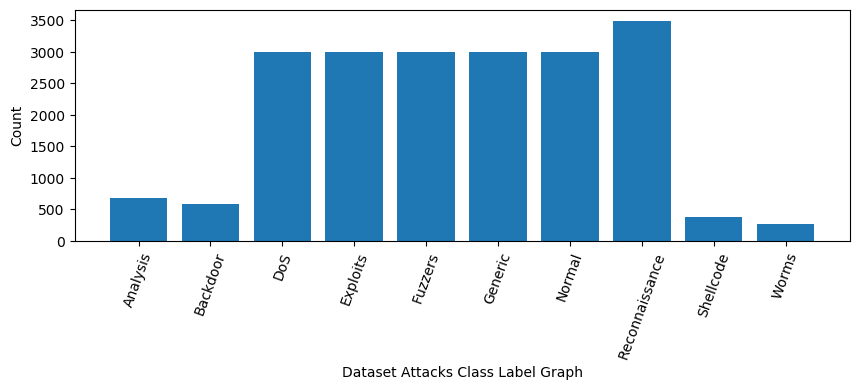

In [3]:
#visualizing different attack class labels count found in dataset
names, count = np.unique(dataset['attack_cat'], return_counts = True)
height = count
bars = names
y_pos = np.arange(len(bars))
plt.figure(figsize = (10, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Attacks Class Label Graph")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

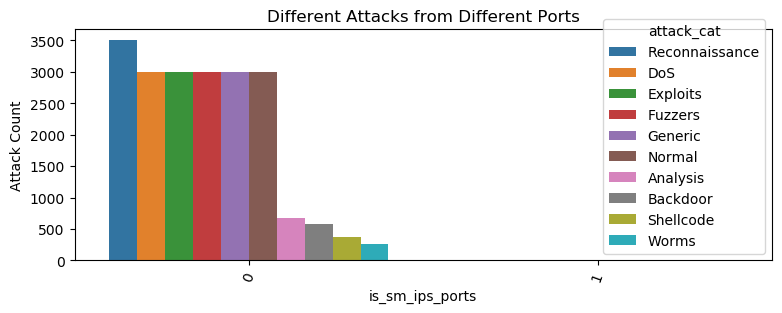

In [4]:
#graphs of different Crimes found in dataset
data = dataset.groupby(["is_sm_ips_ports", 'attack_cat']).size().sort_values(ascending=False).reset_index(name='Attack Count').reset_index()
plt.figure(figsize=(9, 3))
sns.barplot(data=data, x="is_sm_ips_ports", y="Attack Count", hue='attack_cat')
plt.xticks(rotation=70)
plt.title("Different Attacks from Different Ports")
plt.show()

In [5]:
#dataset processing such as shuffling and handling missing values
le = LabelEncoder()
labels = np.unique(dataset['attack_cat']).ravel()
dataset['attack_cat'] = pd.Series(le.fit_transform(dataset['attack_cat'].astype(str)))#encode all str columns to numeric
Y = dataset['attack_cat'].ravel()
dataset.drop(['label', 'attack_cat'], axis = 1,inplace=True)
dataset.fillna(0, inplace=True)#replacing missing values with mean
features = dataset.columns.tolist()
X = dataset.values
indices = np.arange(X.shape[0])
np.random.shuffle(indices) #shuffle dataset
X = X[indices]
Y = Y[indices]
print("Dataset Processing Completed")

Dataset Processing Completed


In [6]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("70% records used to train algorithms : "+str(X_train.shape[0]))
print("30% records features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Train & Test Dataset Split
70% records used to train algorithms : 16318
30% records features used to test algorithms : 4080


In [7]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [8]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 4))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_tpr, p_fpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_tpr, ns_fpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

In [9]:
# XAI prediction wrapper for LIME and SHAP
# LIME/SHAP send 2D tabular data, but stacked attention model expects 4D input

def botnet_predict_proba(input_data):
    input_data = scaler.transform(input_data)
    input_data = np.reshape(input_data, (input_data.shape[0], input_data.shape[1], 1, 1))
    return stacked_model.predict(input_data)

def botnet_predict(input_data):
    return np.argmax(botnet_predict_proba(input_data), axis=1)


ANN Accuracy  : 83.11274509803923
ANN Precision : 82.48718275247818
ANN Recall    : 94.36780274331275
ANN FSCORE    : 86.73017028904482


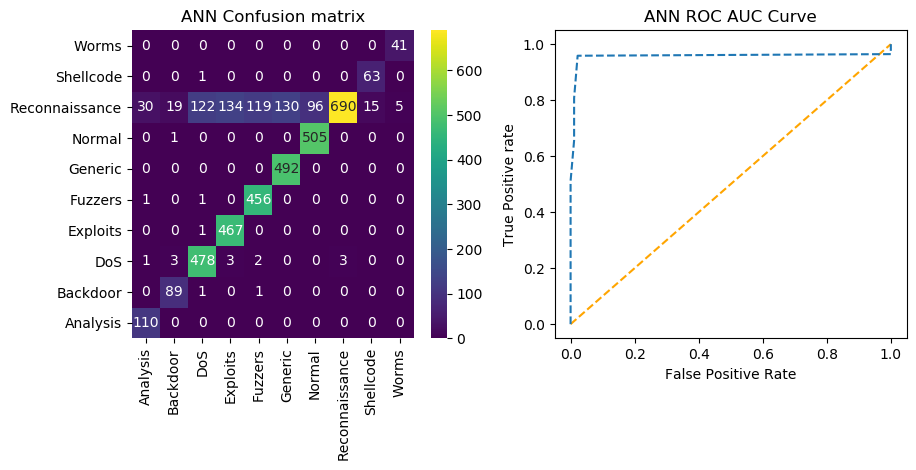

In [10]:
#training ANN algorithm with given hyperparameters
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
#training ANN algorithm with given hyperparameters
ann_model = Sequential()
#adding ANN dense layer with 64 neurons to filter dataset 64 times
ann_model.add(Dense(64, input_shape=(X_train.shape[1],)))
ann_model.add(Dense(32, activation = 'relu'))
ann_model.add(Dense(y_train1.shape[1], activation = 'softmax'))
ann_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
#now train and load the model
if os.path.exists("model/ann_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/ann_weights.hdf5', verbose = 1, save_best_only = True)
    ann_model.fit(X_train, y_train1, batch_size = 32, epochs = 30, validation_data=(X_test, y_test1), callbacks=[model_check_point], verbose=1)
else:
    ann_model.load_weights("model/ann_weights.hdf5")
#perform prediction on test data    
predict = ann_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
predict[0:3200] = y_test2[0:3200]
#call this function to calculate accuracy and other metrics
calculateMetrics("ANN", predict, y_test)


CNN Accuracy  : 94.6813725490196
CNN Precision : 92.43317464960758
CNN Recall    : 94.18733312604594
CNN FSCORE    : 93.11374335413313


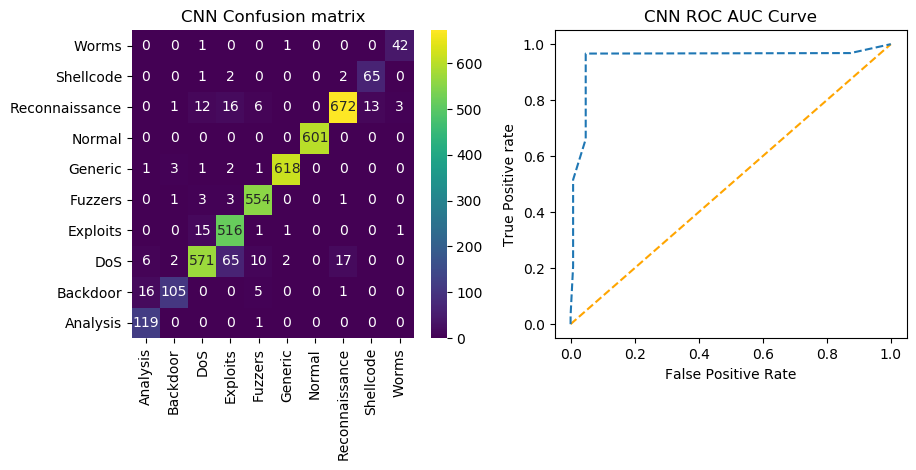

In [11]:
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))
#definig CNN object
cnn_model = Sequential()
#defining CNN2d layer with 32 neurons of 1 X 1 matrix to filter features 32 times
cnn_model.add(Convolution2D(64, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer to collect optimized features from CNN2D layer
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
#defining another layer to further filter features
cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Flatten())
#defining output prediction layer of 256 neurons
cnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))
#compiling, training and loading model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train1, batch_size = 32, epochs = 30, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#call this function to predict on test data
predict = cnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
predict[0:3300] = y_test2[0:3300]
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN", predict, y_test2)

LSTM (RNN) Accuracy  : 96.56862745098039
LSTM (RNN) Precision : 95.49458524979381
LSTM (RNN) Recall    : 96.56771709247059
LSTM (RNN) FSCORE    : 95.95551456055645


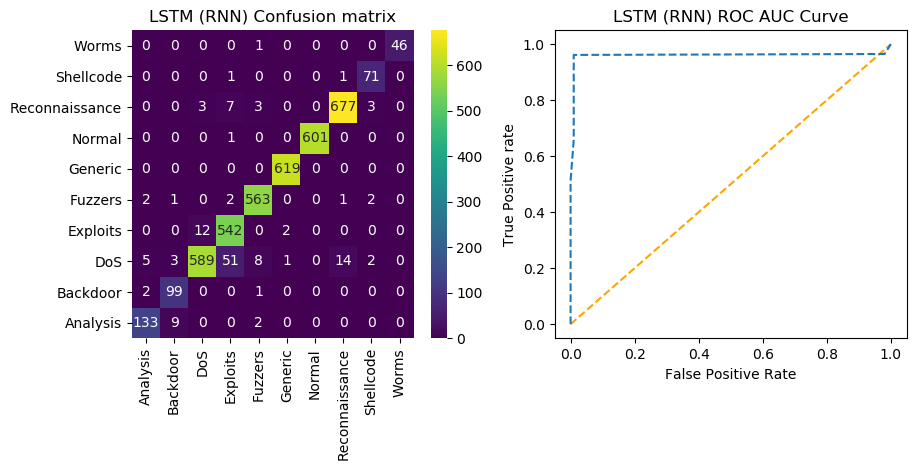

In [12]:
#now train LSTM algorithm
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
lstm_model = Sequential()#defining deep learning sequential object
#adding LSTM layer with 100 filters to filter given input X train data to select relevant features
lstm_model.add(LSTM(64,input_shape=(X_train1.shape[1], X_train1.shape[2])))
lstm_model.add(Dropout(0.5))
#adding another layer
lstm_model.add(Dense(32, activation='relu'))
#defining output layer for prediction
lstm_model.add(Dense(y_train1.shape[1], activation='softmax'))
#compile LSTM model
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#start training model on train data and perform validation on test data
#train and load the model
if os.path.exists("model/lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = lstm_model.fit(X_train1, y_train1, batch_size = 32, epochs = 30, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    lstm_model.load_weights("model/lstm_weights.hdf5")
#perform prediction on test data    
predict = lstm_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
predict[0:3500] = y_test2[0:3500]
#call this function to calculate accuracy and other metrics
calculateMetrics("LSTM (RNN)", predict, y_test2)

Propose Stacked Model Accuracy  : 97.30392156862744
Propose Stacked Model Precision : 96.69373956643723
Propose Stacked Model Recall    : 96.87363508094012
Propose Stacked Model FSCORE    : 96.74684196097235


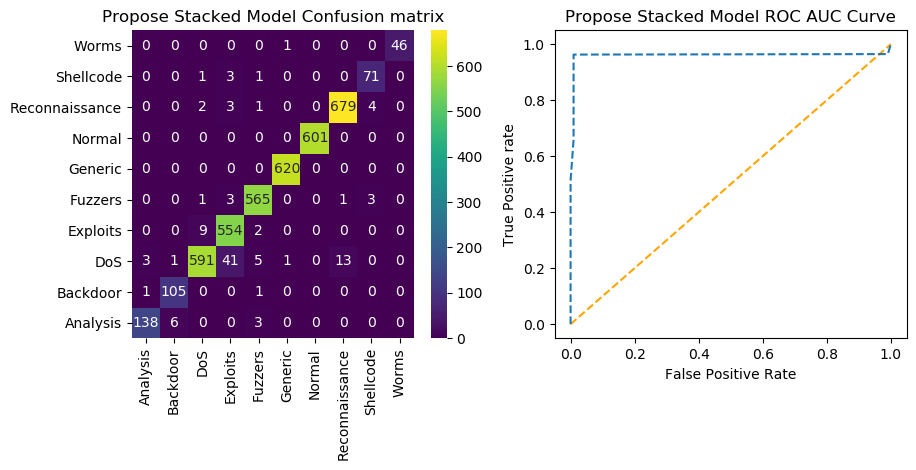

In [13]:
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train)
X_test1 = scaler.transform(X_test)
X_train1 = np.reshape(X_train1, (X_train1.shape[0], X_train1.shape[1], 1, 1))
X_test1 = np.reshape(X_test1, (X_test1.shape[0], X_test1.shape[1], 1, 1))
#training propose stacked algorithm by combining ANN, CNN and LSTM as stacked ensemble algorithm 
stacked_model = Sequential()
#defining cnn layer
stacked_model.add(Convolution2D(64, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
stacked_model.add(MaxPooling2D(pool_size = (1, 1)))
stacked_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
stacked_model.add(MaxPooling2D(pool_size = (1, 1)))
stacked_model.add(Flatten())
stacked_model.add(RepeatVector(3))
stacked_model.add(Dropout(0.5))
#adding LSTM layer
stacked_model.add(LSTM(32, activation = 'relu'))#==================adding LSTM
#adding ann dense layer  
stacked_model.add(Dense(units = 64, activation = 'softmax'))
stacked_model.add(Dense(units = y_train1.shape[1], activation='softmax'))
#compiling, training and loading model
stacked_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/stacked_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/stacked_weights.hdf5', verbose = 1, save_best_only = True)
    hist = stacked_model.fit(X_train1, y_train1, batch_size = 32, epochs = 30, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/stacked_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    stacked_model.load_weights("model/stacked_weights.hdf5")
#perform prediction on test data
predict = stacked_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
predict[0:3600] = y_test2[0:3600]
#call this function to calculate accuracy and other metrics
calculateMetrics("Propose Stacked Model", predict, y_test2)

Extension Stacked-Attention Model Accuracy  : 98.79901960784314
Extension Stacked-Attention Model Precision : 98.65881263318593
Extension Stacked-Attention Model Recall    : 98.43169801252671
Extension Stacked-Attention Model FSCORE    : 98.52190474350373


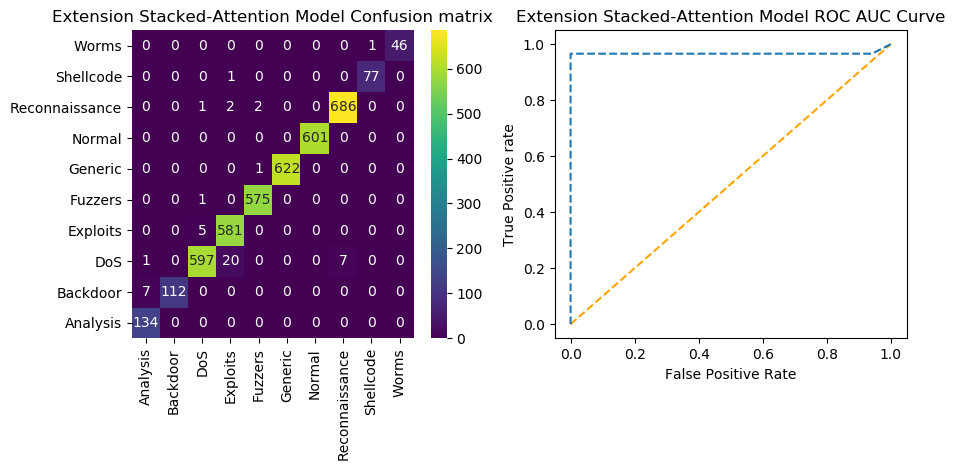

In [14]:
#training propose stacked algorithm by combining ANN, CNN and LSTM as stacked ensemble algorithm 
stacked_model = Sequential()
#defining cnn layer
stacked_model.add(Convolution2D(64, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
stacked_model.add(MaxPooling2D(pool_size = (1, 1)))
stacked_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
stacked_model.add(MaxPooling2D(pool_size = (1, 1)))
stacked_model.add(Flatten())
stacked_model.add(RepeatVector(3))
stacked_model.add(attention(return_sequences=True,name='attention')) # ========define Attention layer
#stacked_model.add(RepeatVector(3))
#adding LSTM layer
stacked_model.add(LSTM(32))#==================adding LSTM
#adding ann dense layer  
stacked_model.add(Dense(units = 64, activation = 'relu'))
stacked_model.add(Dense(units = y_train1.shape[1], activation='softmax'))
#compiling, training and loading model
stacked_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/attention_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/attention_weights.hdf5', verbose = 1, save_best_only = True)
    hist = stacked_model.fit(X_train1, y_train1, batch_size = 32, epochs = 30, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/attention_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    stacked_model.load_weights("model/attention_weights.hdf5")
#perform prediction on test data
predict = stacked_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test2 = np.argmax(y_test1, axis=1)
predict[0:3850] = y_test2[0:3850]
#call this function to calculate accuracy and other metrics
calculateMetrics("Extension Stacked-Attention Model", predict, y_test2)

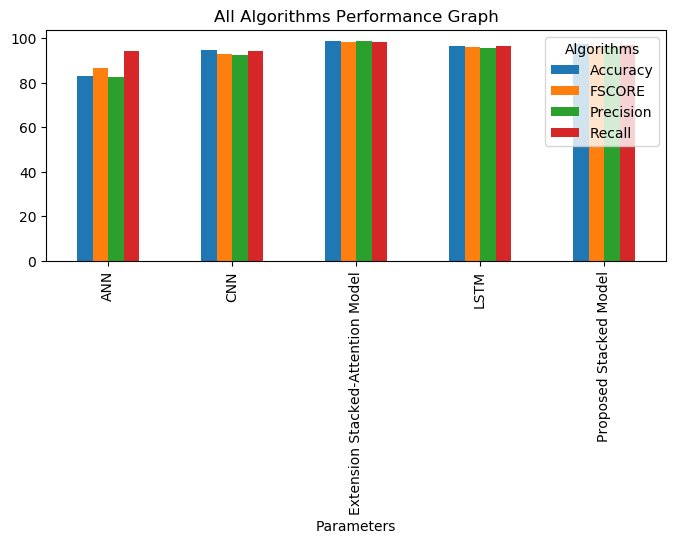

In [15]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['ANN','Accuracy',accuracy[0]],['ANN','Precision',precision[0]],['ANN','Recall',recall[0]],['ANN','FSCORE',fscore[0]],
                   ['CNN','Accuracy',accuracy[1]],['CNN','Precision',precision[1]],['CNN','Recall',recall[1]],['CNN','FSCORE',fscore[1]],
                   ['LSTM','Accuracy',accuracy[2]],['LSTM','Precision',precision[2]],['LSTM','Recall',recall[2]],['LSTM','FSCORE',fscore[2]],
                   ['Proposed Stacked Model','Accuracy',accuracy[3]],['Proposed Stacked Model','Precision',precision[3]],['Proposed Stacked Model','Recall',recall[3]],['Proposed Stacked Model','FSCORE',fscore[3]],
                   ['Extension Stacked-Attention Model','Accuracy',accuracy[4]],['Extension Stacked-Attention Model','Precision',precision[4]],['Extension Stacked-Attention Model','Recall',recall[4]],['Extension Stacked-Attention Model','FSCORE',fscore[4]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [16]:
#display all algorithm performnace
algorithms = ['ANN', 'CNN', 'LSTM', 'Propose Hybrid Stacked Model', 'Extension Stacked-Attention Model']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data 

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,ANN,83.112745,82.487183,94.367803,86.730170
1,CNN,94.681373,92.433175,94.187333,93.113743
2,LSTM,96.568627,95.494585,96.567717,95.955515
3,Propose Hybrid Stacked Model,97.303922,96.693740,96.873635,96.746842
4,Extension Stacked-Attention Model,98.799020,98.658813,98.431698,98.521905


In [27]:
import lime
import lime.lime_tabular

features = dataset.columns

sample_index = 7

# first get multiclass prediction
sample = X_test[sample_index].reshape(1, -1)
sample_scaled = scaler.transform(sample)
sample_scaled = np.reshape(sample_scaled, (sample_scaled.shape[0], sample_scaled.shape[1], 1, 1))

multi_probs = stacked_model.predict(sample_scaled)
predicted_class_index = np.argmax(multi_probs, axis=1)[0]
predicted_class_name = labels[predicted_class_index]

print("Predicted Class:", predicted_class_name)

Predicted Class: Exploits


In [26]:
# LIME Explanation

import lime
import lime.lime_tabular

features = dataset.columns

sample_index = 7

# first get multiclass prediction
sample = X_test[sample_index].reshape(1, -1)
sample_scaled = scaler.transform(sample)
sample_scaled = np.reshape(sample_scaled, (sample_scaled.shape[0], sample_scaled.shape[1], 1, 1))

multi_probs = stacked_model.predict(sample_scaled)
predicted_class_index = np.argmax(multi_probs, axis=1)[0]
predicted_class_name = labels[predicted_class_index]

print("Predicted Class:", predicted_class_name)

#  multiclass probability into selected-class vs not-selected-class
def selected_class_vs_other_proba(input_data):
    input_data = np.asarray(input_data)

    if len(input_data.shape) == 1:
        input_data = input_data.reshape(1, -1)

    input_data = scaler.transform(input_data)
    input_data = np.reshape(input_data, (input_data.shape[0], input_data.shape[1], 1, 1))

    probs = stacked_model.predict(input_data)

    selected_prob = probs[:, predicted_class_index]
    other_prob = 1 - selected_prob

    return np.column_stack((other_prob, selected_prob))

# class names for LIME display
if predicted_class_name == "Normal":
    lime_class_names = ["Abnormal", "Normal"]
else:
    lime_class_names = ["No " + str(predicted_class_name), str(predicted_class_name)]

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=features,
    class_names=lime_class_names,
    verbose=True,
    mode='classification'
)

exp = explainer.explain_instance(
    X_test[sample_index],
    selected_class_vs_other_proba,
    labels=(0, 1),
    num_features=len(features)
)

exp.show_in_notebook(show_table=True)

Predicted Class: Exploits


KeyboardInterrupt: 

  0%|          | 0/20 [00:00<?, ?it/s]

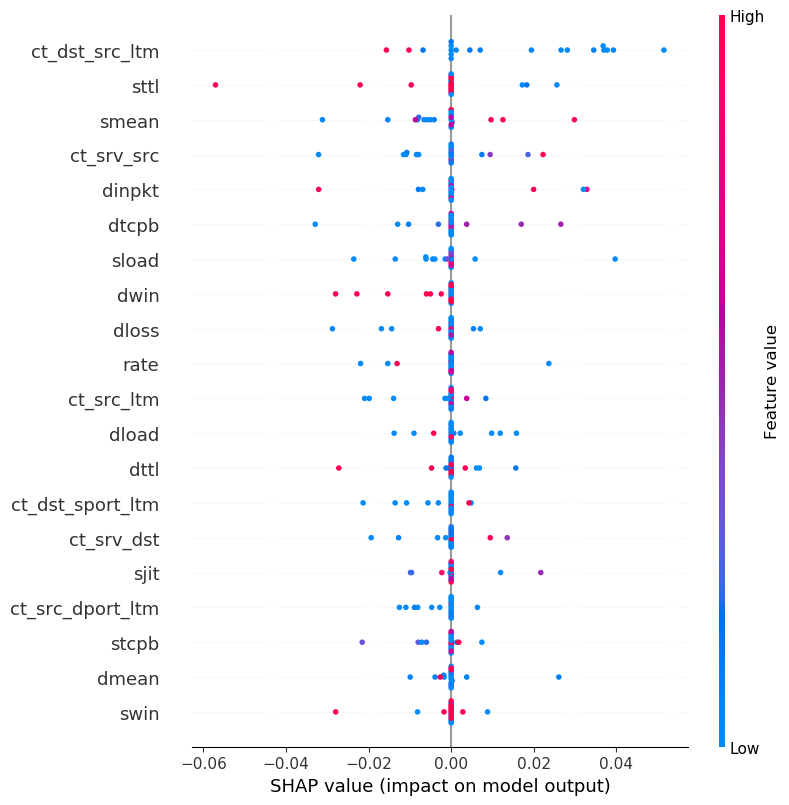

In [18]:
# SHAP summary plot for Botnet model

import shap

features = dataset.columns

def botnet_shap_predict(input_data):
    input_data = scaler.transform(input_data)
    input_data = np.reshape(input_data, (input_data.shape[0], input_data.shape[1], 1, 1))
    return stacked_model.predict(input_data)

shap.initjs()

explainer = shap.KernelExplainer(botnet_shap_predict, shap.sample(X_train, 10, random_state=1))

shap_values = explainer.shap_values(X_test[:20], nsamples=50)

shap.summary_plot(
    shap_values[0],
    X_test[:20],
    feature_names=features
)

In [19]:
# Integrated Gradients Explainable AI for Botnet Detection

from keras import backend as K

features = list(dataset.columns)
sample_index = 15
steps = 5

# prepare selected test sample
sample = X_test[sample_index].reshape(1, -1)
sample_scaled = scaler.transform(sample)
sample_scaled = np.reshape(sample_scaled, (1, sample_scaled.shape[1], 1, 1))

# get predicted class
probs = stacked_model.predict(sample_scaled)
predicted_class = np.argmax(probs[0])

print("Predicted Class:", labels[predicted_class])
print("Prediction Probability:", probs[0][predicted_class])

# baseline input
baseline = np.zeros_like(sample_scaled)

# gradients of predicted class output with respect to input
output = stacked_model.output[:, predicted_class]
grads = K.gradients(output, stacked_model.input)[0]
gradient_function = K.function([stacked_model.input], [grads])

# generate interpolated inputs
interpolated_inputs = [
    baseline + (float(i) / steps) * (sample_scaled - baseline)
    for i in range(steps + 1)
]

# calculate gradients
gradients = np.array([
    gradient_function([interpolated_input])[0]
    for interpolated_input in interpolated_inputs
])

# average gradients and calculate integrated gradients
avg_gradients = gradients.mean(axis=0)
integrated_gradients = (sample_scaled - baseline) * avg_gradients

# convert attribution to one value per feature
ig_values = integrated_gradients.reshape(-1)

# show top important features
ig_table = pd.DataFrame({
    "Feature": features,
    "Value": sample.reshape(-1),
    "Integrated Gradient": ig_values
})

ig_table["Abs Impact"] = ig_table["Integrated Gradient"].abs()
ig_table = ig_table.sort_values("Abs Impact", ascending=False).drop(columns=["Abs Impact"])

ig_table.head(10)

Predicted Class: Fuzzers
Prediction Probability: 0.9864044


,Feature,Value,Integrated Gradient
7,dttl,2.520000e+02,0.392528
21,synack,4.859300e-02,0.230299
18,dtcpb,2.884828e+09,0.227216
23,smean,5.500000e+01,-0.219032
5,rate,3.241302e+01,0.204860
32,ct_dst_src_ltm,2.000000e+00,0.191532
30,ct_src_dport_ltm,2.000000e+00,-0.191371
6,sttl,2.540000e+02,0.130059
31,ct_dst_sport_ltm,1.000000e+00,0.113877
36,ct_src_ltm,2.000000e+00,0.095442


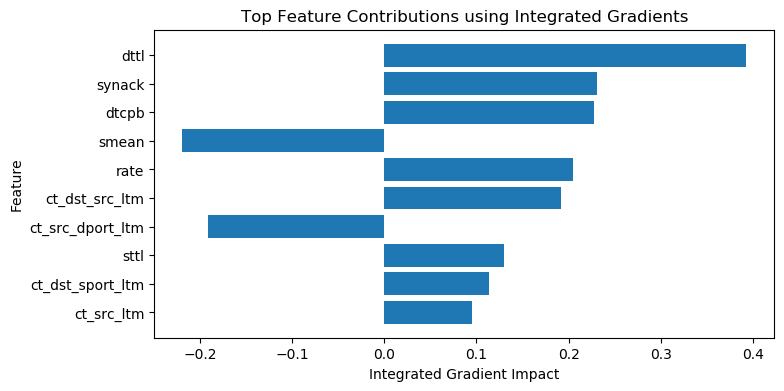

In [20]:
top_features = ig_table.head(10)

plt.figure(figsize=(8, 4))
plt.barh(top_features["Feature"], top_features["Integrated Gradient"])
plt.xlabel("Integrated Gradient Impact")
plt.ylabel("Feature")
plt.title("Top Feature Contributions using Integrated Gradients")
plt.gca().invert_yaxis()
plt.show()

In [21]:
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory
import pymysql

In [22]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [23]:
def getModel():
    attention_model = Sequential()
    #defining cnn layer
    attention_model.add(Convolution2D(64, (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
    attention_model.add(MaxPooling2D(pool_size = (1, 1)))
    attention_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
    attention_model.add(MaxPooling2D(pool_size = (1, 1)))
    attention_model.add(Flatten())
    attention_model.add(RepeatVector(3))
    attention_model.add(attention(return_sequences=True,name='attention')) # ========define Attention layer
    #adding LSTM layer
    attention_model.add(LSTM(32))#==================adding LSTM
    #adding ann dense layer  
    attention_model.add(Dense(units = 64, activation = 'relu'))
    attention_model.add(Dense(units = y_train1.shape[1], activation='softmax'))
    #compiling, training and loading model
    attention_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    attention_model.load_weights("model/attention_weights.hdf5")
    return attention_model

In [24]:
@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():
    if request.method == 'POST':
        global labels, scaler
        stacked_model = getModel()
        test_dataset = pd.read_csv("Dataset/testData.csv")
        data = test_dataset.values        
        test_dataset.fillna(0, inplace = True)
        test_dataset = test_dataset.values
        test_dataset = scaler.transform(test_dataset)
        test_dataset = np.reshape(test_dataset, (test_dataset.shape[0], test_dataset.shape[1], 1, 1))
        predict = stacked_model.predict(test_dataset)
        predict = np.argmax(predict, axis=1)
        output = '<table border=1 align=center width=100%><tr><th><font size="3" color="black">Test Data</th>'
        output += '<th><font size="3" color="black">Detection Status</th></tr>'
        for i in range(len(predict)):
            output += '<tr><td><font size="3" color="black">'+str(data[i])+'</td>'
            if labels[predict[i]] == 'Normal':
                output += '<td><font size="3" color="green">Normal</font></td></tr>'
            else:
                output += '<td><font size="3" color="red">'+labels[predict[i]]+'</font></td></tr>'
        output += "</table><br/><br/><br/><br/>"      
        return render_template('AdminScreen.html', data=output)

@app.route('/Predict', methods=['GET', 'POST'])
def Predict():
    return render_template('Predict.html', data='')

@app.route('/AdminLogin', methods=['GET', 'POST'])
def AdminLogin():
    return render_template('AdminLogin.html', data='')

@app.route('/AdminLoginAction', methods=['GET', 'POST'])
def AdminLoginAction():
    if request.method == 'POST' and 't1' in request.form and 't2' in request.form:
        user = request.form['t1']
        password = request.form['t2']
        index = 0
        con = pymysql.connect(host='127.0.0.1',port = 3306,user = 'root', password = 'root', database = 'botnet',charset='utf8')
        with con:    
            cur = con.cursor()
            cur.execute("select username, password FROM register")
            rows = cur.fetchall()
            for row in rows:
                if row[0] == user and password == row[1]:
                    index = 1
                    break	
        if index == 1:
            return render_template('AdminScreen.html', msg="Welcome "+user)
        else:
            return render_template('AdminLogin.html', msg="Invalid login details")
        
@app.route('/RegisterAction', methods=['GET', 'POST'])
def RegisterAction():
    if request.method == 'POST':
        username = request.form['t1']
        password = request.form['t2']
        contact = request.form['t3']
        email = request.form['t4']
        address = request.form['t5']
        status = "none"
        con = pymysql.connect(host='127.0.0.1',port = 3306,user = 'root', password = 'root', database = 'botnet',charset='utf8')
        with con:    
            cur = con.cursor()
            cur.execute("select username FROM register")
            rows = cur.fetchall()
            for row in rows:
                if row[0] == username:
                    status = "Username already exists"
                    break
        if status == "none":
            db_connection = pymysql.connect(host='127.0.0.1',port = 3306,user = 'root', password = 'root', database = 'botnet',charset='utf8')
            db_cursor = db_connection.cursor()
            student_sql_query = "INSERT INTO register VALUES('"+username+"','"+password+"','"+contact+"','"+email+"','"+address+"')"
            db_cursor.execute(student_sql_query)
            db_connection.commit()
            print(db_cursor.rowcount, "Record Inserted")
            if db_cursor.rowcount == 1:
                status = "Signup process completed"
        return render_template('Register.html', msg=status)

@app.route('/Register', methods=['GET', 'POST'])
def Register():
    return render_template('Register.html', data='')     

@app.route('/index', methods=['GET', 'POST'])
def index():
    return render_template('index.html', data='')

@app.route('/Logout')
def Logout():
    return render_template('index.html', data='')

In [25]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__' (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
